**Model 4 - Swin Transformer**

In [ ]:
!pip install timm -q

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Random Seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

# Paths
DATA_DIR = "/content/drive/MyDrive/research_data"

CHECKPOINT_PATH = os.path.join(DATA_DIR, "checkpoint_swin.pth")
BEST_MODEL_PATH = os.path.join(DATA_DIR, "best_swin.pth")

print("Checkpoint :", CHECKPOINT_PATH)
print("Best Model :", BEST_MODEL_PATH)

Device : cuda
GPU : Tesla T4
Checkpoint : /content/drive/MyDrive/research_data/checkpoint_swin.pth
Best Model : /content/drive/MyDrive/research_data/best_swin.pth


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/research_data/train.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/research_data/val.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/research_data/test.csv")

print("Train Samples      :", len(train_df))
print("Validation Samples :", len(val_df))
print("Test Samples       :", len(test_df))

train_df.head()

Train Samples      : 8470
Validation Samples : 1815
Test Samples       : 1815


,image_path,label
0,/content/drive/MyDrive/research_data/final_dat...,fake
1,/content/drive/MyDrive/research_data/final_dat...,fake
2,/content/drive/MyDrive/research_data/final_dat...,fake
3,/content/drive/MyDrive/research_data/final_dat...,fake
4,/content/drive/MyDrive/research_data/final_dat...,real


In [ ]:
print(train_df["label"].value_counts())
print()
print(val_df["label"].value_counts())
print()
print(test_df["label"].value_counts())

label
fake    4970
real    3500
Name: count, dtype: int64

label
fake    1065
real     750
Name: count, dtype: int64

label
fake    1065
real     750
Name: count, dtype: int64


In [ ]:
train_df.head()

,image_path,label
0,/content/drive/MyDrive/research_data/final_dat...,fake
1,/content/drive/MyDrive/research_data/final_dat...,fake
2,/content/drive/MyDrive/research_data/final_dat...,fake
3,/content/drive/MyDrive/research_data/final_dat...,fake
4,/content/drive/MyDrive/research_data/final_dat...,real


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms Ready")

Transforms Ready


In [ ]:
class BrainDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        # Image path
        img_path = self.df.loc[idx, "image_path"]

        # Label
        label = self.df.loc[idx, "label"]

        # Convert label to integer
        # fake -> 0
        # real -> 1
        if label == "real":
            label = 1
        else:
            label = 0

        # Read image
        image = Image.open(img_path).convert("RGB")

        # Apply transforms
        if self.transform is not None:
            image = self.transform(image)

        # Return image and label
        return image, torch.tensor(label, dtype=torch.long)


In [ ]:
train_dataset = BrainDataset(train_df, train_transform)
val_dataset   = BrainDataset(val_df, test_transform)
test_dataset  = BrainDataset(test_df, test_transform)

print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(val_dataset))
print("Test Dataset :", len(test_dataset))

Train Dataset : 8470
Validation Dataset : 1815
Test Dataset : 1815


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 265
Validation batches : 57
Test batches : 57


In [ ]:
NUM_CLASSES = 2

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

print("Loss, Optimizer and Scheduler Ready")

Loss, Optimizer and Scheduler Ready


In [ ]:
start_epoch = 0
best_val_acc = 0.0

print("Starting Fresh Training")

Starting Fresh Training


In [ ]:
import torch
import torch.nn as nn

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

# No Scheduler
scheduler = None

print("Loss, Optimizer and Scheduler Ready")

Loss, Optimizer and Scheduler Ready


In [ ]:
# ===============================
# Fresh Training (No Checkpoint)
# ===============================

start_epoch = 0
best_val_acc = 0.0

print("=" * 60)
print("🚀 Starting Fresh Swin Transformer Training")
print("Checkpoint loading is disabled.")
print(f"Training will start from Epoch {start_epoch + 1}")
print("=" * 60)

🚀 Starting Fresh Swin Transformer Training
Checkpoint loading is disabled.
Training will start from Epoch 1


In [ ]:
import os
import torch

start_epoch = 0
best_val_acc = 0.0

if os.path.exists(CHECKPOINT_PATH):

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    # Agar scheduler use kar rahe ho aur save kiya tha
    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]

    print("=" * 60)
    print("✅ Checkpoint Loaded")
    print(f"Resuming from Epoch {start_epoch + 1}")
    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print("=" * 60)

else:

    print("=" * 60)
    print("No Checkpoint Found")
    print("Starting Fresh Training")
    print("=" * 60)

No Checkpoint Found
Starting Fresh Training


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

# ==============================
# TRAINING CONFIG
# ==============================
start_epoch = 0
best_val_acc = 0.0
num_epochs = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

# ==============================
# TRAINING LOOP
# ==============================

for epoch in range(start_epoch, num_epochs):

    print("="*60)
    print(f"Epoch {epoch+1}/{num_epochs}")

    # ==========================================
    # TRAINING
    # ==========================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        if batch_idx % 20 == 0:
            print(f"Training Batch {batch_idx}/{len(train_loader)}")

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ==========================================
    # VALIDATION
    # ==========================================

    model.eval()

    val_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch_idx, (images, labels) in enumerate(val_loader):

            if batch_idx % 10 == 0:
                print(f"Validation Batch {batch_idx}/{len(val_loader)}")

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    #scheduler.step(val_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print("-"*50)
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")

    # ==========================================
    # SAVE BEST MODEL
    # ==========================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("✅ Best Model Saved")

    # ==========================================
    # SAVE CHECKPOINT
    # ==========================================

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            #"scheduler_state_dict": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
        },
        CHECKPOINT_PATH,
    )

    print("💾 Checkpoint Saved")

print("="*60)
print("🎉 Training Completed!")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")

Epoch 1/10
Training Batch 0/265
Training Batch 20/265
Training Batch 40/265
Training Batch 60/265
Training Batch 80/265
Training Batch 100/265
Training Batch 120/265
Training Batch 140/265
Training Batch 160/265
Training Batch 180/265
Training Batch 200/265
Training Batch 220/265
Training Batch 240/265
Training Batch 260/265
Validation Batch 0/57
Validation Batch 10/57
Validation Batch 20/57
Validation Batch 30/57
Validation Batch 40/57
Validation Batch 50/57
--------------------------------------------------
Train Loss : 0.3129
Train Acc  : 0.8848
Val Loss   : 0.3173
Val Acc    : 0.9003
Precision  : 0.9596
Recall     : 0.7920
F1 Score   : 0.8678
✅ Best Model Saved
💾 Checkpoint Saved
Epoch 2/10
Training Batch 0/265
Training Batch 20/265
Training Batch 40/265
Training Batch 60/265
Training Batch 80/265
Training Batch 100/265
Training Batch 120/265
Training Batch 140/265
Training Batch 160/265
Training Batch 180/265
Training Batch 200/265
Training Batch 220/265
Training Batch 240/265
Tra

In [ ]:
print(device)

cuda


Loading Best Swin Transformer Model
FINAL TEST RESULTS
Accuracy  : 0.9229
Precision : 0.9967
Recall    : 0.8160
F1 Score  : 0.8974
AUC Score : 0.9249

Classification Report

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1065
           1       1.00      0.82      0.90       750

    accuracy                           0.92      1815
   macro avg       0.94      0.91      0.92      1815
weighted avg       0.93      0.92      0.92      1815



<Figure size 600x600 with 0 Axes>

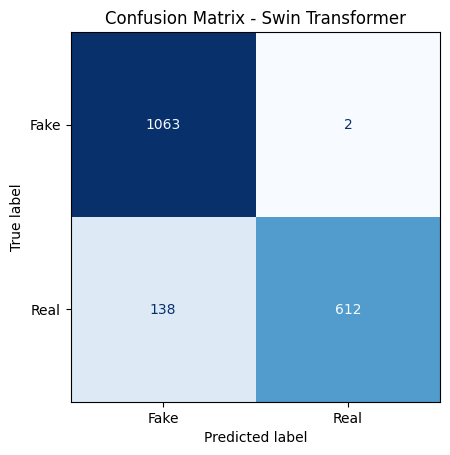

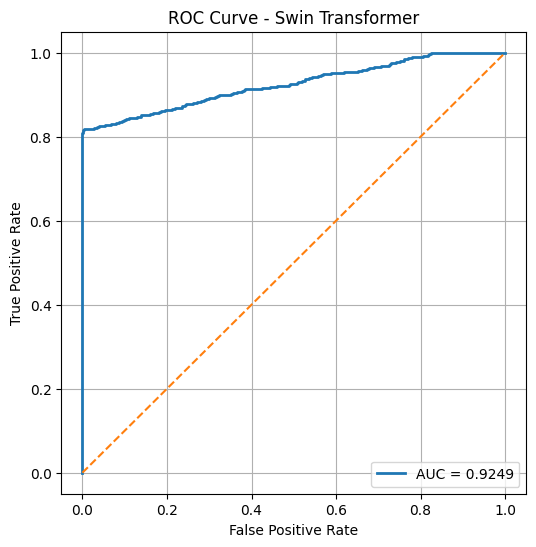

Evaluation Completed Successfully!


In [ ]:
# ===========================
# FINAL EVALUATION (Run After Training)
# ===========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

print("="*60)
print("Loading Best Swin Transformer Model")
print("="*60)

checkpoint = torch.load(BEST_MODEL_PATH)

# Handle both checkpoint dict and plain state_dict
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ===========================
# Metrics
# ===========================

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc_score = roc_auc_score(all_labels, all_probs)

print("="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc_score:.4f}")

print("\nClassification Report\n")
print(classification_report(all_labels, all_preds))

# ===========================
# Confusion Matrix
# ===========================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Swin Transformer")
plt.show()

# ===========================
# ROC Curve
# ===========================

fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Swin Transformer")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("="*60)
print("Evaluation Completed Successfully!")
print("="*60)